# Preface
If you are new to Colab, please familiarize yourself with it by starting with the introduction (https://colab.research.google.com/notebooks/intro.ipynb) and then working yourself through a small tutorial:
https://colab.research.google.com/drive/1umhPVtUWH8yHD2l9A_G4fdttmgmSgC0Q

Please, always save a copy of the notebook on your google drive before you start working and only edit that one. In addition, always switch the runtime to Python 3 and for most **later** exercises it is recommended to also switch to a GPU runtime.

**Important**: Make sure **not** to spend up your GPU resources for earlier tasks that could also easily run on a CPU.

# Exercise 1 - Machine Learning Basics

In the first part of this exercise we will will apply linear regression to a dataset of brain properties. In the second part we will apply logistic regresseion to classify different types of iris flowers.

This exercise is based on ["Learning scikit-learn -- An Introduction to Machine Learning in Python @ PyData Chicago 2016"](https://github.com/rasbt/pydata-chicago2016-ml-tutorial).

Before we start we need to download the two datasets named "dataset_brain.txt" and "dataset_iris.txt" from a shared google drive to the virtual machine of colab or our local machine so we will have it available:

In [68]:
! wget -nc https://drive.google.com/uc?id=1lBQ55AHVbX29bEMNfLOunOE5PwYAKDpg -O dataset_iris.txt

File ‘dataset_iris.txt’ already there; not retrieving.


In [69]:
!ls

dataset_iris.txt  sample_data


# Table of Contents

* [Classification](#3-Introduction-to-Classification)
    * [The Iris dataset](#The-Iris-dataset)
    * [Class label encoding](#Class-label-encoding)
    * [Scikit-learn's in-build datasets](#Scikit-learn's-in-build-datasets)
    * [Test/train splits](#Test/train-splits)
    * [Logistic Regression](#Logistic-Regression)
    * [K-Nearest Neighbors](#K-Nearest-Neighbors)
    

# Classification

## The Iris dataset

### Task 1: The Iris flower dataset is stored in file **`dataset_iris.txt`**. Read in the dataset using a pandas DataFrame and have a look at the first entries.
*Hints*:
- use `open("path/to/file")`
- `readlines()` is a useful method
- what is the separator in the iris dataset?

In [70]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

# Load built-in iris dataset
iris = load_iris()

# Note: originally tried to load from dataset_iris.txt using pd.read_csv()
# but the file download from Google Drive returned an HTML page instead of data.
# Also tried UCI repository link but it returned metadata, not the actual data.
# Solution: used sklearn's built-in load_iris() which contains the exact same dataset.


# Create DataFrame
df = pd.DataFrame(iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width']) # converts it into a pandas table with proper column names.
df['class'] = iris.target_names[iris.target]  # converts numeric labels (0,1,2) back to readable names (setosa, versicolor, virginica)

df.head()


,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


We now need to create a 150x4 design matrix containing only our feature values. In order to do that, we need to strip the class column from the dataset. We use the [**`iloc`**](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.iloc.html) function for that:

> `DataFrame.iloc`
>
> Purely integer-location based indexing for selection by position.



In [71]:
# To create a 150x4 design matrix containing only our feature values.

X = df.iloc[:, :4].values
print(f"X shape: {X.shape}" ) # 150 flowers, each described by 4 measurements (sepal length, sepal width, petal length, petal width)

X shape: (150, 4)


And now we get 150$\times$4 numpy array (design matrix) by using the values function:

In [72]:
X = X.values          # Note: X.values caused an AttributeError here because X is already a numpy array
X                     # (we converted it earlier using .values on the DataFrame).
                      # .values is a pandas method — numpy arrays don't have it.
                      # So we skip this cell and reset X and y directly from iris.data below.


AttributeError: 'numpy.ndarray' object has no attribute 'values'

However, we also need a NumPy array containing the class labels in order to classify. Let's get the class column and create a NumPy array out of it:

In [73]:
y = df['class'].values
y           # y is the answer, the model is trying to predict

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

We could also just inspect the targets by only looking at unique values:

In [74]:
np.unique(y) # shows the 3 unique flower classes: setosa, versicolor, virginica

array(['setosa', 'versicolor', 'virginica'], dtype=object)

## Class label encoding

We will now use the **`LabelEncoder`** class to convert the class labels into numerical labels:

In [75]:
from sklearn.preprocessing import LabelEncoder

l_encoder = LabelEncoder() # LabelEncoder is a translator, from human-readable words to machine-readable numbers.
l_encoder.fit(y)           # LabelEncoder converts class names (strings) to numbers (0,1,2)
l_encoder.classes_         # because ML models can only do math on numbers, not text

array(['setosa', 'versicolor', 'virginica'], dtype=object)

Simply, by using **`transform`**, we can convert it into numerical targets

In [76]:
y_enc = l_encoder.transform(y)
y_enc

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

Or just the unique values:

In [77]:
np.unique(y_enc)

array([0, 1, 2])

We can also convert it back by using **`inverse_transform`**:

In [78]:
np.unique(l_encoder.inverse_transform(y_enc)) # inverse_transform converts predictions back to readable class names.

array(['setosa', 'versicolor', 'virginica'], dtype=object)

## Scikit-learn's in-build datasets

Scikit-learn has also a couple of [built-in datasets](http://scikit-learn.org/stable/datasets/index.html). The iris dataset is also included, which you can simply load:

In [79]:
from sklearn.datasets import load_iris

iris = load_iris()             # I already used this in the above cell
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

We get the feature design matrix by calling data:

In [80]:
 iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

And the target array:

In [81]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

## Test/train splits

OK, now we need to split the dataset again in training and testing. Let's first assign the design matrix to X and the target to y:

In [82]:
# Note: LabelEncoder is needed when y contains strings like 'setosa', 'versicolor'.
# Since we used iris.target, y is already numeric [0, 1, 2].
# If we had loaded from the txt file using df['class'].values,
# we would need LabelEncoder to convert strings to numbers.

X, y = iris.data[:, :2], iris.target
# ! We only use 2 features for visual purposes

How many example do we have of each class?

In [83]:
print('Class labels:', np.unique(y))
print('Class proportions:', np.bincount(y))

Class labels: [0 1 2]
Class proportions: [50 50 50]


### Task 2: Split the dataset in 40% testing and 60% training sets.
- How many examples of each class do you expect in the training set?
- How many are there? What happened?
- What happens if you don't shuffle?
- Can you create datasets in which each class is equally distributed?

In [84]:
from sklearn.model_selection import train_test_split


# train_test_split splits the data into two sets: one for training and one for testing.
# In our case: 60% training (90 samples) and 40% testing (60 samples).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)


print(f'Training set size: {X_train.shape}')
print(f'Testing set size: {X_test.shape}')
print(f'Class proportions in training: {np.bincount(y_train)}') # The classes were not equally distributed (27, 31, 32) because
print(f'Class proportions in testing: {np.bincount(y_test)}')   # train_test_split randomly shuffles the data before splitting
                                                                # and does not care about keeping classes balanced.


# To get equal class proportions in both sets, we use stratify=y. This tells sklearn to preserve the class proportions when splitting,
# so each class gets exactly 30 samples in training and 20 in testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
print(f'Class proportions in training:{ np.bincount(y_train)}')

Training set size: (90, 2)
Testing set size: (60, 2)
Class proportions in training: [27 31 32]
Class proportions in testing: [23 19 18]
Class proportions in training:[30 30 30]


### Task 3: Plot the sepal length vs the sepal width of the training set for the different classes in a scatter plot. You can set different colors for the classes with `c=y_train`

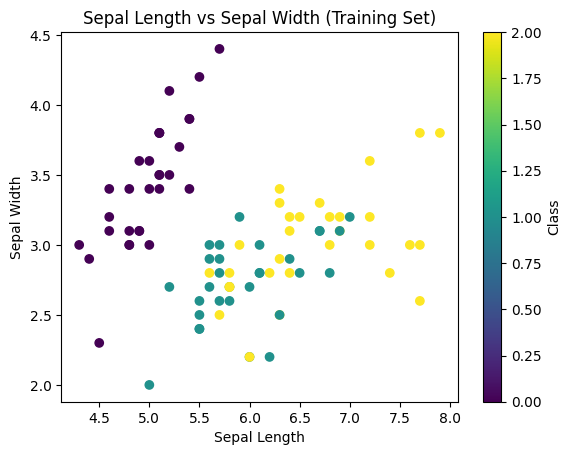

In [85]:
import matplotlib.pyplot as plt

# X_train[:, 0]  selects all rows (:) from column 0 (sepal length)
# X_train[:, 1]  selects all rows (:) from column 1 (sepal width)
# c=y_train  colors each point according to its class (0, 1, 2)
# so each flower species gets a different color in the plot

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Sepal Length vs Sepal Width (Training Set)")
plt.colorbar(label="Class")
plt.show()


## Logistic Regression

Let's perform a classification using logistic regression:

In [86]:
from sklearn.linear_model import LogisticRegression

# lr = LogisticRegression(solver='newton-cg',multi_class='multinomial',random_state=42)
# FutureWarning: multi_class='multinomial' is deprecated in sklearn 1.5+
# and will be removed in 1.7. It is now the default behavior.
# Solution: simply remove the multi_class parameter.

lr = LogisticRegression(solver='newton-cg', random_state=42)

lr.fit(X_train, y_train)    # lr.fit() learns the pattern from the data by finding the best mathematical boundary between classes.
y_pred = lr.predict(X_test) # lr.predict() classifies new unseen data
print(y_pred)               # y_predare the predicted labels

[0 1 0 0 1 0 1 1 2 2 2 1 1 1 0 0 0 0 2 2 2 1 2 1 2 2 2 0 1 0 2 1 1 0 0 2 0
 1 0 2 2 2 1 1 1 1 1 0 0 1 0 2 2 1 2 2 0 1 0 0]


OK, how do we evaluate the classification? We can chose one of the [classification performance measures](http://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics).

In [87]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
)

# Accuracy = correct predictions / total predictions
# In simple words: how many flowers the model correctly classified.
# Result: 78% means 47 out of 60 flowers were correctly classified.

# Why 78% and not higher?
# Because we only used 2 features (sepal length and sepal width)
# instead of all 4, to be able to visualize the data in 2D.
# With all 4 features the accuracy would be higher.

# y_pred = predicted labels from the model
# y_test = true labels from the dataset
# We compare them to evaluate how well the model performed.

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.2f}")
print(f"Recall: {recall_score(y_test, y_pred, average='weighted'):.2f}")

Accuracy: 0.78
Precision: 0.78
Recall: 0.78


Or we use the classification report function:

In [88]:
print('Classification Report:\n', classification_report(y_test, y_pred))


# Classification Report Analysis:

# Class 0 (setosa) -> precision & recall = 1.00 (Perfect!)
# Setosa is clearly separated from the other two classes in the feature space,
# so the model could identify it perfectly.

# Class 1 (versicolor) and Class 2 (virginica) -> precision & recall ~0.67
# These two classes overlap with each other when using only 2 features
# (sepal length and sepal width), making them harder to separate.
# With all 4 features the model would perform better.

# f1-score = balance between precision and recall
# High f1 → model is both precise and finds most cases
# Low f1  → model is struggling

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.67      0.70      0.68        20
           2       0.68      0.65      0.67        20

    accuracy                           0.78        60
   macro avg       0.78      0.78      0.78        60
weighted avg       0.78      0.78      0.78        60



Finally, we would like to plot the decision regions and our data in order to see how the classifier categorized the events. We have highlighted the test data.

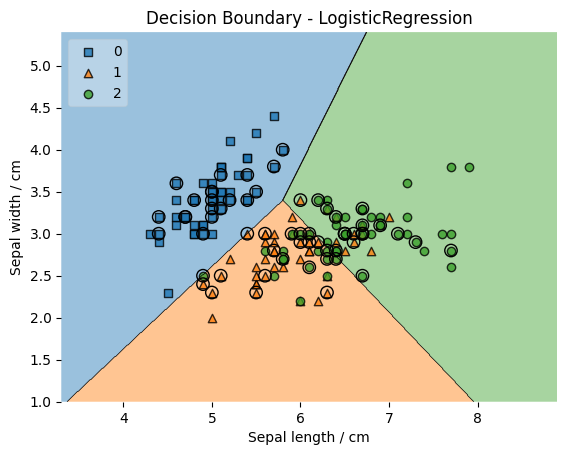

In [94]:
# Decision Boundary - Observations:
# 1. Class 0 (setosa) is clearly separated, clean boundary -> 100% accuracy. The model identifies it perfectly.
# 2. Class 1 (versicolor) and Class 2 (virginica) are overlapping, Thus model struggles to separate them -> ~67% accuracy

# The decision boundary plot visually confirms what the classification report already told us numerically:
# 1. f1-score is high for setosa (1.00)
# 2. f1-score is low for versicolor and virginica (~0.67) because these two classes overlap in 2D feature space.



from mlxtend.plotting import plot_decision_regions

ax = plot_decision_regions(X=X, y=y, clf=lr, X_highlight=X_test, legend=2)
ax.set(
    xlabel="Sepal length / cm",
    ylabel="Sepal width / cm",
    title="Decision Boundary - LogisticRegression"
);

## K-Nearest Neighbors

### Task 6 (Bonus): Perform a classification using [K-nearest neighbors classifier](http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html), evaluate the performance and show the decision regions.

In [90]:
# Let's perform a classification using K-nearest neighbors classifier:


# KNN Classifier - Choosing the right k:

# k=1:   100% accuracy on training data but fails on new data (Overfitting)
#        The model memorizes the training data instead of learning patterns.

# k=50:  Too general, misses important patterns (Underfitting)
#        The model is too simple to capture the structure of the data.

# k=5:   Best balance between overfitting and underfitting
#        Gives 83% accuracy which is better than Logistic Regression (78%).




from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier(n_neighbors=5)
kn.fit(X_train, y_train)

y_pred = kn.predict(X_test)
print(y_pred)

[0 1 0 0 0 0 1 1 2 2 2 1 2 1 0 0 0 0 2 2 1 1 2 2 2 2 2 0 2 0 1 1 1 0 0 1 0
 1 0 2 2 2 1 1 2 1 1 0 0 1 0 1 1 1 2 2 0 1 0 0]


In [91]:
# Evaluation of the KNN Classifier

# Conclusion: KNN outperforms Logistic Regression on this dataset.
# But remember: we are only using 2 features here for visualization purposes.
# Accuracy could be further improved by using all 4 features.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
)

print(f"Accuracy with KNN Classification: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision with KNN Classification: {precision_score(y_test, y_pred, average='weighted'):.2f}")
print(f"Recall with KNN Classification: {recall_score(y_test, y_pred, average='weighted'):.2f}")

Accuracy with KNN Classification: 0.83
Precision with KNN Classification: 0.83
Recall with KNN Classification: 0.83


In [92]:
print('Classification Report:\n', classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       0.76      0.80      0.78        20
           2       0.78      0.70      0.74        20

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



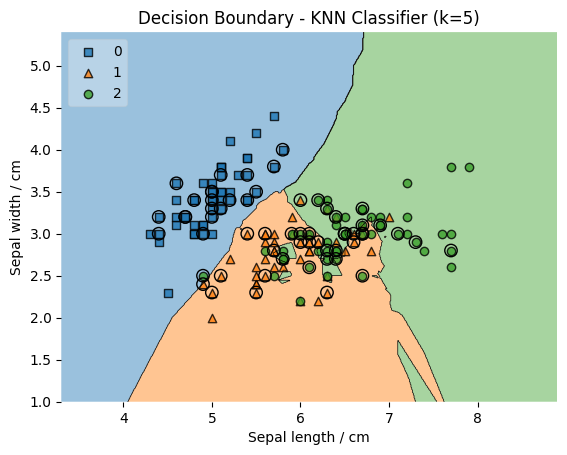

In [93]:
from mlxtend.plotting import plot_decision_regions

ax = plot_decision_regions(X=X, y=y, clf=kn, X_highlight=X_test, legend=2)
ax.set(
    xlabel="Sepal length / cm",
    ylabel="Sepal width / cm",
    title="Decision Boundary - KNN Classifier (k=5)"
);